# P17-M04 — LSTM 3 Layer (CNN 32→64→128 | LSTM 128→128→64 | Drop 0.5)
### SIBI Lip Reading — Input: Lucas-Kanade Optical Flow P17 — Dataset Gabungan (18 Kelas)

**Input data:** `flows_lk_p17/` — output preprocessing Notebook 04c  
**Arsitektur:** identik M04, hanya sumber input berubah dari RGB → optical flow (u, v, magnitude)  
**Variasi M04:** Menambah kedalaman temporal dengan 3 ConvLSTM layer (128→128→64).

| | Baseline | M04 (ini) |
|---|---|---|
| CNN channels | 32→64→128 | 32→64→128 |
| LSTM hiddens | 128→64 | **128→128→64** |
| Dropout | 0.5 | 0.5 |

In [1]:
import json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM    : 8.09 GB


In [2]:
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
FLOWS_DIR    = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'flows_lk_p17'  # input P17
MODELS_DIR   = PROJECT_ROOT / 'models' / 'lk_p17' / 'M04'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'lk_p17' / 'M04'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES      = cfg['data']['classes']
NUM_CLASSES  = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}

VARIANT_ID   = 'P17-M04'
CNN_CHANNELS = [32, 64, 128]
LSTM_HIDDENS = [128, 128, 64]      # 3 layer LSTM: 128→128→64
DROPOUT      = 0.5
FC_HIDDEN    = 256
SEQ_LEN      = 29             # T-1 dari 30 frame raw (flow = 29 frame)

BATCH_SIZE   = 8
NUM_EPOCHS   = 100
LR           = 0.001
WEIGHT_DECAY = 1e-5
SEED         = 42

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)

print(f'Variant  : {VARIANT_ID}')
print(f'Input    : {FLOWS_DIR}')
print(f'CNN ch   : {CNN_CHANNELS}')
print(f'LSTM h   : {LSTM_HIDDENS}  ← 3 layer (128→128→64)')
print(f'Seq len  : {SEQ_LEN} frames (optical flow T-1)')
print(f'Classes  : {NUM_CLASSES} — {CLASSES}')
print(f'Results  → {RESULTS_DIR}')

Variant  : P17-M04
Input    : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lk_p17
CNN ch   : [32, 64, 128]
LSTM h   : [128, 128, 64]  ← 3 layer (128→128→64)
Seq len  : 29 frames (optical flow T-1)
Classes  : 18 — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
Results  → /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/results/lk_p17/M04


In [3]:
class LKFlowDataset(Dataset):
    """
    Load optical flow .npy [T-1, H, W, 3] → tensor [3, T-1, H, W].
    Data SUDAH ternormalisasi (clip + z-score) dari Notebook 04c — jangan dibagi 255!
    Augmentasi: horizontal flip + negate channel u (semantik-benar untuk optical flow).
    """
    def __init__(self, root, classes, split, seq_len=29, augment=False):
        self.samples, self.labels = [], []
        self.seq_len = seq_len
        self.augment = augment
        for idx, cls in enumerate(classes):
            d = Path(root) / split / cls
            if not d.exists(): print(f'  Warning: {d} tidak ditemukan'); continue
            for f in sorted(d.glob('*.npy')):
                self.samples.append(f); self.labels.append(idx)
        print(f'  {split:5s}: {len(self.samples)} samples')

    def _fix_len(self, s):
        T = len(s)
        if T == self.seq_len: return s
        if T < self.seq_len:
            pad = np.zeros((self.seq_len - T, *s.shape[1:]), dtype=np.float32)
            return np.concatenate([s, pad])
        return s[np.linspace(0, T - 1, self.seq_len, dtype=int)]

    def _aug(self, s):
        if np.random.random() > 0.5:
            s = s[:, :, ::-1, :].copy()   # flip horizontal
            s[..., 0] *= -1               # negate u channel (wajib!)
        return s

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        seq = np.load(self.samples[i]).astype(np.float32)   # [T-1, H, W, 3] — sudah normalized
        if self.augment: seq = self._aug(seq)
        seq = self._fix_len(seq)                             # [SEQ_LEN, H, W, 3]
        seq = torch.from_numpy(seq.transpose(3, 0, 1, 2))   # [3, SEQ_LEN, H, W]
        return seq, torch.tensor(self.labels[i], dtype=torch.long)

print('Loading datasets...')
train_ds = LKFlowDataset(FLOWS_DIR, CLASSES, 'train', SEQ_LEN, augment=True)
val_ds   = LKFlowDataset(FLOWS_DIR, CLASSES, 'val',   SEQ_LEN, augment=False)
test_ds  = LKFlowDataset(FLOWS_DIR, CLASSES, 'test',  SEQ_LEN, augment=False)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

x, y = next(iter(train_loader))
print(f'\nBatch shape : {x.shape}  (expected [8, 3, {SEQ_LEN}, 96, 96])')
print(f'Value range : [{x.min():.3f}, {x.max():.3f}]  (sudah ternormalisasi, bukan 0-1)')
print(f'Label sample: {[IDX_TO_CLASS[l.item()] for l in y]}')

Loading datasets...
  train: 2519 samples
  val  : 720 samples
  test : 359 samples

Batch shape : torch.Size([8, 3, 29, 96, 96])  (expected [8, 3, 29, 96, 96])
Value range : [-2.432, 2.918]  (sudah ternormalisasi, bukan 0-1)
Label sample: ['8', 'b', 'sekarang', '3', '9', 'keliling', 'kelompok', '2']


In [4]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, h_ch, k=3):
        super().__init__()
        self.h_ch = h_ch
        self.conv = nn.Conv2d(in_ch + h_ch, 4 * h_ch, k, padding=k // 2)

    def forward(self, x, state):
        h, c = state
        i, f, o, g = torch.split(self.conv(torch.cat([x, h], dim=1)), self.h_ch, dim=1)
        c_next = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, B, H, W, dev):
        return (torch.zeros(B, self.h_ch, H, W, device=dev),
                torch.zeros(B, self.h_ch, H, W, device=dev))


class ConvLSTMModel(nn.Module):
    """
    Input : [B, 3, T, H, W]  — 3 ch = u, v, magnitude (optical flow P17)
    Output: [B, num_classes]
    cnn_channels : list channel CNN backbone
    lstm_hiddens : list hidden ConvLSTM (fleksibel 2 atau 3 layer)
    """
    def __init__(self, num_classes, cnn_channels, lstm_hiddens, dropout=0.5, fc_hidden=256):
        super().__init__()

        def cblock(ic, oc):
            return nn.Sequential(nn.Conv2d(ic, oc, 3, padding=1),
                                 nn.BatchNorm2d(oc), nn.ReLU(), nn.MaxPool2d(2))
        layers, prev = [], 3
        for ch in cnn_channels:
            layers.append(cblock(prev, ch)); prev = ch
        self.cnn = nn.Sequential(*layers)

        self.lstm_cells = nn.ModuleList()
        in_ch = prev
        for h_ch in lstm_hiddens:
            self.lstm_cells.append(ConvLSTMCell(in_ch, h_ch))
            in_ch = h_ch

        self.head = nn.Sequential(
            nn.Linear(lstm_hiddens[-1], fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes)
        )

    def forward(self, x):
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
        x = self.cnn(x)
        _, c, h, w = x.shape
        x = x.view(B, T, c, h, w)
        states = [cell.init_hidden(B, h, w, x.device) for cell in self.lstm_cells]
        for t in range(T):
            inp = x[:, t]
            for li, cell in enumerate(self.lstm_cells):
                states[li] = cell(inp, states[li])
                inp = states[li][0]
        out = states[-1][0].mean(dim=[-2, -1])  # GAP
        return self.head(out)


model = ConvLSTMModel(NUM_CLASSES, CNN_CHANNELS, LSTM_HIDDENS, DROPOUT, FC_HIDDEN).to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb    = total_params * 4 / 1e6

with torch.no_grad():
    out_test = model(torch.randn(2, 3, SEQ_LEN, 96, 96).to(device))

print(f'Variant      : {VARIANT_ID}')
print(f'Total params : {total_params:,}')
print(f'Model size   : {model_size_mb:.2f} MB')
print(f'Forward test : [2, 3, {SEQ_LEN}, 96, 96] → {out_test.shape}  ✓')

Variant      : P17-M04
Total params : 2,917,906
Model size   : 11.67 MB
Forward test : [2, 3, 29, 96, 96] → torch.Size([2, 18])  ✓


In [5]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, leave=False, desc='Train' if train else 'Eval '):
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            preds_all.extend(out.argmax(1).cpu().tolist())
            labels_all.extend(y.cpu().tolist())
    return total_loss / len(loader.dataset), 100 * accuracy_score(labels_all, preds_all), preds_all, labels_all

def per_class_str(labels, preds):
    res = []
    for i, cls in enumerate(CLASSES):
        tot = sum(l == i for l in labels)
        if tot == 0: continue
        acc = round(100 * sum(p == i for p, l in zip(preds, labels) if l == i) / tot)
        res.append(f'{cls}:{acc}%')
    return '  '.join(res)

history   = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[], 'epoch_time':[]}
best_val  = 0.0; best_ep = 0
best_path = MODELS_DIR / f'{VARIANT_ID}_best.pth'
t0_total  = time.time()

print(f'Training {VARIANT_ID} — {NUM_EPOCHS} epochs | {NUM_CLASSES} kelas\n')
for ep in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, _, _       = run_epoch(train_loader, train=True)
    va_loss, va_acc, va_p, va_l = run_epoch(val_loader,   train=False)
    scheduler.step(va_acc)
    cur_lr = optimizer.param_groups[0]['lr']
    ep_t   = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)
    history['epoch_time'].append(ep_t)

    mark = ''
    if va_acc > best_val:
        best_val = va_acc; best_ep = ep
        torch.save({'model_state': model.state_dict(), 'epoch': ep,
                    'val_acc': va_acc, 'variant': VARIANT_ID,
                    'flow_config': 'P17', 'lstm_hiddens': LSTM_HIDDENS}, best_path)
        mark = '  <-- best'

    print(f'{ep:4d}  loss={tr_loss:.4f} tr={tr_acc:.2f}%  val={va_acc:.2f}%  lr={cur_lr:.2e}  {ep_t:.0f}s{mark}')
    if ep % 5 == 0 or mark:
        print(f'       per-class: {per_class_str(va_l, va_p)}')

total_time = time.time() - t0_total
print(f'\nTraining selesai! Best val={best_val:.2f}% di epoch {best_ep} | Total={total_time/60:.1f} menit')

Training P17-M04 — 100 epochs | 18 kelas



Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

   1  loss=2.9015 tr=5.00%  val=5.56%  lr=1.00e-03  76s  <-- best
       per-class: 1:0%  2:100%  3:0%  8:0%  9:0%  10:0%  a:0%  b:0%  c:0%  d:0%  e:0%  f:0%  buku:0%  dia:0%  saya:0%  keliling:0%  kelompok:0%  sekarang:0%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

  99  loss=0.0038 tr=100.00%  val=42.92%  lr=3.13e-05  76s


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

 100  loss=0.0039 tr=99.92%  val=43.89%  lr=3.13e-05  76s
       per-class: 1:55%  2:78%  3:32%  8:70%  9:42%  10:50%  a:65%  b:42%  c:20%  d:28%  e:20%  f:42%  buku:30%  dia:55%  saya:20%  keliling:50%  kelompok:65%  sekarang:25%

Training selesai! Best val=45.42% di epoch 89 | Total=126.9 menit


In [6]:
ckpt = torch.load(best_path, weights_only=False)
model.load_state_dict(ckpt['model_state'])
te_loss, te_acc, te_p, te_l = run_epoch(test_loader, train=False)

report    = classification_report(te_l, te_p, target_names=CLASSES, output_dict=True)
f1_macro  = report['macro avg']['f1-score'] * 100
f1_weight = report['weighted avg']['f1-score'] * 100
prec_w    = report['weighted avg']['precision'] * 100
rec_w     = report['weighted avg']['recall'] * 100

class_accs = []
for i in range(NUM_CLASSES):
    tot = sum(l == i for l in te_l)
    class_accs.append(100 * sum(p == i for p, l in zip(te_p, te_l) if l == i) / tot if tot else 0)

print(f'=== Hasil Test {VARIANT_ID} ===')
print(f'Test Accuracy  : {te_acc:.2f}%')
print(f'F1 Weighted    : {f1_weight:.2f}%')
print(f'F1 Macro       : {f1_macro:.2f}%')
print(f'Precision (w)  : {prec_w:.2f}%')
print(f'Recall (w)     : {rec_w:.2f}%')
print(f'Best Epoch     : {best_ep}/{NUM_EPOCHS}')
print(f'Best Val Acc   : {best_val:.2f}%')
print('\nPer-class accuracy:')
for cls, acc in zip(CLASSES, class_accs):
    flag = '✓' if acc >= 80 else ('△' if acc >= 50 else '✗')
    print(f'  {flag} {cls:12s}: {acc:.1f}%')

Eval :   0%|          | 0/45 [00:00<?, ?it/s]

=== Hasil Test P17-M04 ===
Test Accuracy  : 43.73%
F1 Weighted    : 44.27%
F1 Macro       : 44.29%
Precision (w)  : 46.62%
Recall (w)     : 43.73%
Best Epoch     : 89/100
Best Val Acc   : 45.42%

Per-class accuracy:
  △ 1           : 55.0%
  △ 2           : 55.0%
  ✗ 3           : 20.0%
  △ 8           : 55.0%
  △ 9           : 63.2%
  △ 10          : 65.0%
  △ a           : 50.0%
  △ b           : 50.0%
  △ c           : 50.0%
  ✗ d           : 40.0%
  ✗ e           : 25.0%
  ✗ f           : 40.0%
  ✗ buku        : 35.0%
  ✗ dia         : 40.0%
  ✗ saya        : 10.0%
  ✗ keliling    : 45.0%
  △ kelompok    : 60.0%
  ✗ sekarang    : 30.0%


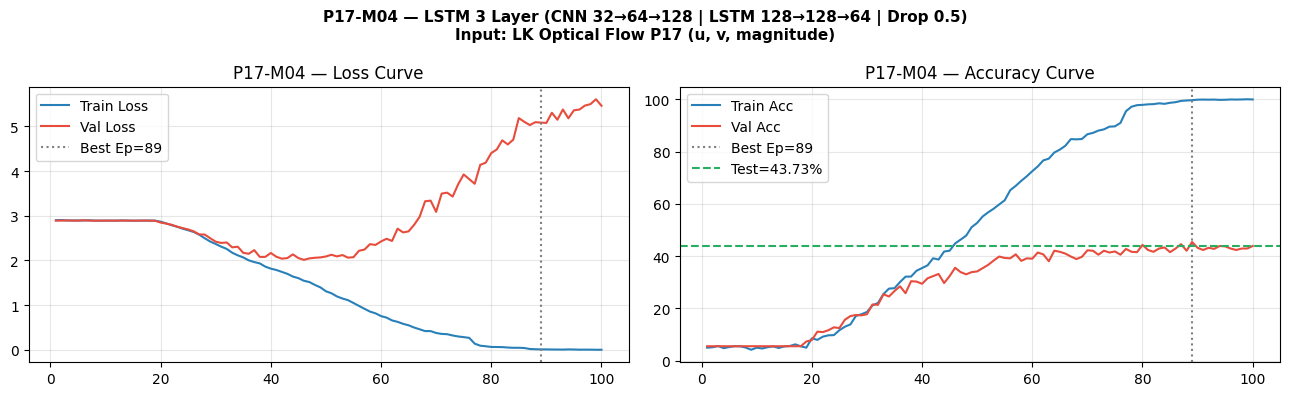

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
eps = range(1, len(history['train_acc']) + 1)

axes[0].plot(eps, history['train_loss'], label='Train Loss', color='#2980B9')
axes[0].plot(eps, history['val_loss'],   label='Val Loss',   color='#E74C3C')
axes[0].axvline(best_ep, color='gray', linestyle=':', label=f'Best Ep={best_ep}')
axes[0].set_title(f'{VARIANT_ID} — Loss Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, history['train_acc'], label='Train Acc', color='#2980B9')
axes[1].plot(eps, history['val_acc'],   label='Val Acc',   color='#E74C3C')
axes[1].axvline(best_ep, color='gray', linestyle=':', label=f'Best Ep={best_ep}')
axes[1].axhline(te_acc, color='#27AE60', linestyle='--', label=f'Test={te_acc:.2f}%')
axes[1].set_title(f'{VARIANT_ID} — Accuracy Curve')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(
    f'{VARIANT_ID} — LSTM 3 Layer (CNN 32→64→128 | LSTM 128→128→64 | Drop 0.5)\n'
    f'Input: LK Optical Flow P17 (u, v, magnitude)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

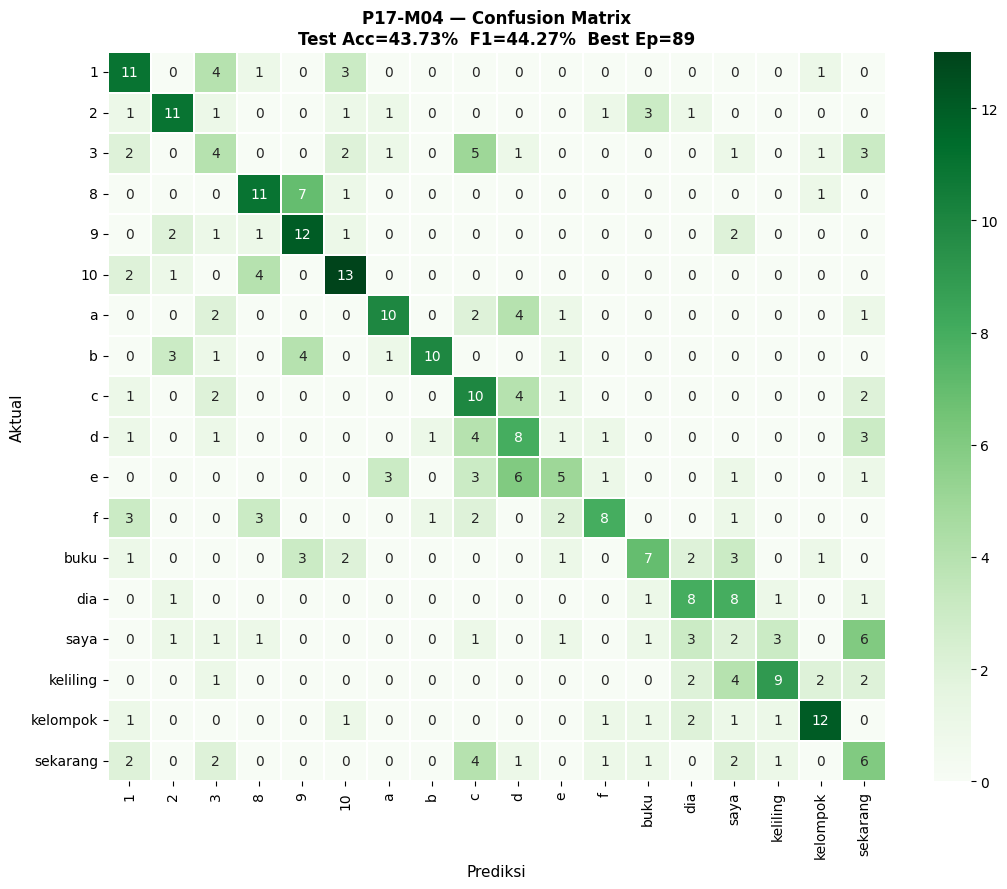

In [8]:
cm  = confusion_matrix(te_l, te_p)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, linewidths=0.3)
ax.set_xlabel('Prediksi', fontsize=11)
ax.set_ylabel('Aktual', fontsize=11)
ax.set_title(
    f'{VARIANT_ID} — Confusion Matrix\n'
    f'Test Acc={te_acc:.2f}%  F1={f1_weight:.2f}%  Best Ep={best_ep}',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

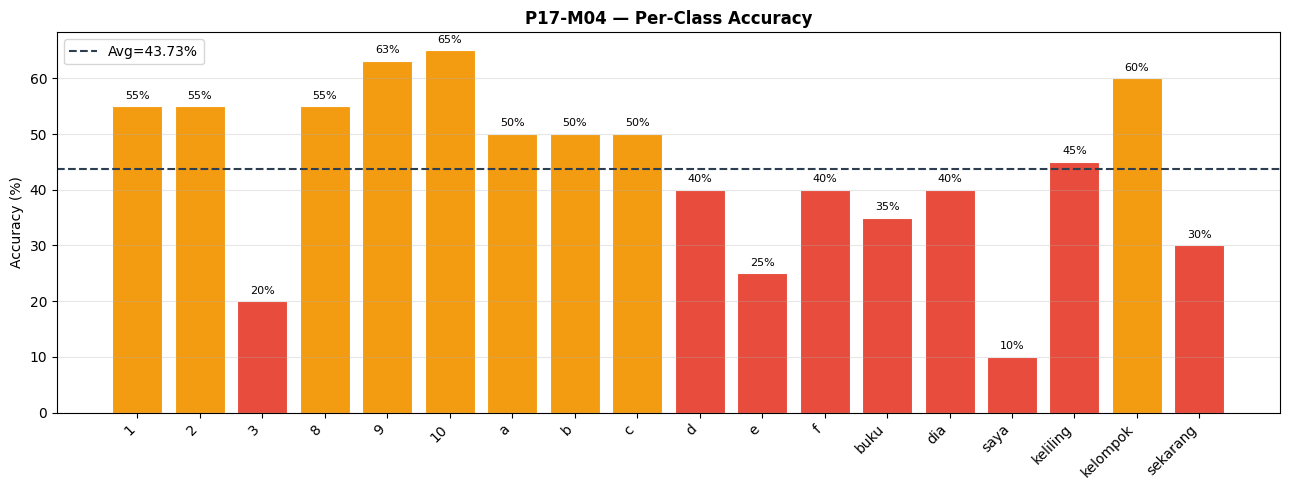

In [9]:
x_pos  = np.arange(NUM_CLASSES)
colors = ['#27AE60' if a >= 80 else ('#F39C12' if a >= 50 else '#E74C3C') for a in class_accs]
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(x_pos, class_accs, color=colors, edgecolor='white', linewidth=0.8)
for bar, acc in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.0f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(te_acc, color='#2C3E50', linestyle='--', linewidth=1.5, label=f'Avg={te_acc:.2f}%')
ax.set_xticks(x_pos); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'{VARIANT_ID} — Per-Class Accuracy', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
summary = {
    'variant_id'  : VARIANT_ID,
    'variant_name': f'{VARIANT_ID} — LSTM 3 Layer (CNN 32→64→128 | LSTM 128→128→64 | Drop 0.5)',
    'flow_config' : 'P17 (maxCorners=300, qualityLevel=0.005, blockSize=6)',
    'config': {
        'cnn_channels': CNN_CHANNELS,
        'lstm_hiddens': LSTM_HIDDENS,
        'dropout'     : DROPOUT,
        'fc_hidden'   : FC_HIDDEN,
        'seq_len'     : SEQ_LEN,
        'input_channels': 'u, v, magnitude (optical flow P17)'
    },
    'training': {
        'total_params': total_params, 'trainable_params': trainable_params,
        'model_size_mb': round(model_size_mb, 2),
        'best_epoch': best_ep, 'best_val_acc': round(best_val, 4),
        'batch_size': BATCH_SIZE, 'lr': LR, 'weight_decay': WEIGHT_DECAY,
        'total_time_min': round(total_time / 60, 2),
        'avg_epoch_sec' : round(sum(history['epoch_time']) / len(history['epoch_time']), 1)
    },
    'test_results': {
        'test_loss': round(te_loss, 4), 'accuracy': round(te_acc, 4),
        'f1_macro': round(f1_macro, 4), 'f1_weighted': round(f1_weight, 4),
        'precision_weighted': round(prec_w, 4), 'recall_weighted': round(rec_w, 4),
        'per_class_acc': {CLASSES[i]: round(class_accs[i], 2) for i in range(NUM_CLASSES)}
    }
}
with open(RESULTS_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    'epoch': range(1, len(history['train_loss'])+1),
    'train_loss': history['train_loss'], 'train_acc': history['train_acc'],
    'val_loss'  : history['val_loss'],   'val_acc'  : history['val_acc'],
    'lr': history['lr'], 'epoch_time': history['epoch_time']
}).to_csv(RESULTS_DIR / 'training_history.csv', index=False)

pd.DataFrame(
    [{'class': cls, **{k: round(report[cls][k]*100, 2) for k in ['precision','recall','f1-score']},
      'support': int(report[cls]['support'])} for cls in CLASSES]
).to_csv(RESULTS_DIR / 'classification_report.csv', index=False)

print(f'=== {VARIANT_ID} — Semua Hasil Tersimpan ===')
for fname in ['summary.json','training_history.csv','classification_report.csv',
              'training_curves.png','confusion_matrix.png','per_class_accuracy.png']:
    p = RESULTS_DIR / fname
    print(f'  [{"✓" if p.exists() else "✗"}] {fname}')
print(f'\nTest Accuracy : {te_acc:.2f}%')
print(f'F1 Weighted   : {f1_weight:.2f}%')
print(f'Best Epoch    : {best_ep}/{NUM_EPOCHS}')
print(f'Model saved   : {best_path}')

=== P17-M04 — Semua Hasil Tersimpan ===
  [✓] summary.json
  [✓] training_history.csv
  [✓] classification_report.csv
  [✓] training_curves.png
  [✓] confusion_matrix.png
  [✓] per_class_accuracy.png

Test Accuracy : 43.73%
F1 Weighted   : 44.27%
Best Epoch    : 89/100
Model saved   : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/models/lk_p17/M04/P17-M04_best.pth
